Размер исходных данных: (144, 3)

Первые 5 строк:
   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None

Статистика:
              year  passengers
count   144.000000  144.000000
mean   1954.500000  280.298611
std       3.464102  119.966317
min    1949.000000  104.000000
25%    1951.750000  180.000000
50%    1954.500000  265.500000
75%    1957.250000  360.500000
max    1960.000000  622.000000

Пропуски:
year          0
month         0
passengers    0
dtype: int64

Размер после фильтрации по летним мес

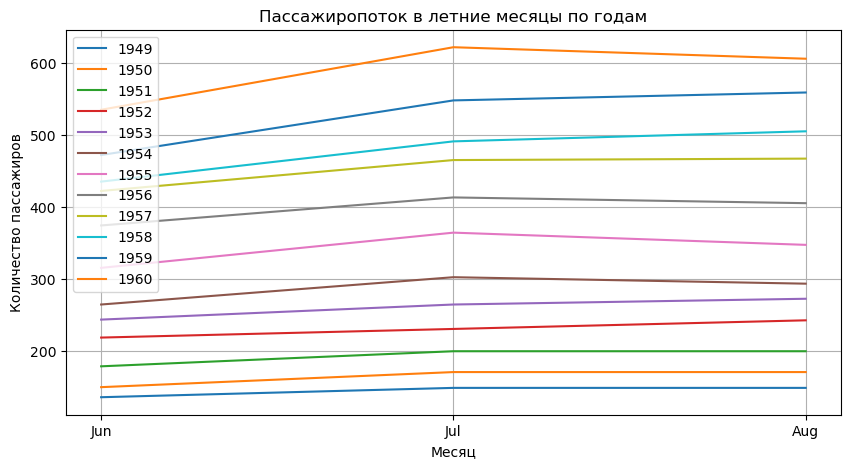


Предобработка завершена. Размер итогового датасета: (36, 5)


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('flights')
print("Размер исходных данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())
print("\nСтатистика:")
print(df.describe())
print("\nПропуски:")
print(df.isnull().sum())

#обработка пропусков (их нет)
if df.isnull().sum().sum() > 0:
    df = df.interpolate()

df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str)

#season по месяцу
def get_season(month):
    if month in ['Jan', 'Feb', 'Dec']:
        return 'winter'
    elif month in ['Mar', 'Apr', 'May']:
        return 'spring'
    elif month in ['Jun', 'Jul', 'Aug']:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month'].apply(get_season)

#фильтрация данных (только летние месяцы)
df_summer = df[df['season'] == 'summer']
print("\nРазмер после фильтрации по летним месяцам:", df_summer.shape)

#графики
plt.figure(figsize=(10, 5))
for year in df_summer['year'].unique():
    year_data = df_summer[df_summer['year'] == year]
    plt.plot(year_data['month'], year_data['passengers'], label=str(year))

plt.title('Пассажиропоток в летние месяцы по годам')
plt.xlabel('Месяц')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.grid(True)
plt.show()

df_summer.to_csv('flights_cleaned.csv', index=False)
print("\nПредобработка завершена. Размер итогового датасета:", df_summer.shape)